## **Notes**

**Video Processing Legacy Notes**

Feb 2022 - Lane Breshears, modified from .py code Alex Day

Mar 2023 - Yisha Tang, modified for eNAMPT: check the example boards before running video analysis; merge multichannel data to one sheet and give threshold-cleaned flow profile

Feb 2024 - Yisha Tang, modified for PFAS: new section of data analysis and visualization to further clean the flow profile, analyze flow rate at adjustable time range.

Mar 14 2024: Use the maxiuma variation to locate the initial start if variation doesn't meet the threshold; new funtion - drop the messy data.

Mar 3/20/2024 - Lexi DeFord started modifying this code branch for Micro/Nano plastic detection

Use with any microfluidic chip, place the black line over the channel to analyze flow across the channel. Specify number of channels and channel gaps.

Apr 2024 - Yisha Tang, implemented batch processing for Lexi

October 2024 - Jocelyn Reynolds, implemented upgrades to batch processing to only process new videos and to work around API issues

Use with any microfluidic chip, place the black line over the channel to analyze flow across the channel. Specify number of channels and channel gaps.


**EdgeMaster Notes**

Nov 2024 by Lexi DeFord for analyzing all MNP experiments for Round_2

"Batch of Batches" - Running video processing on several folders serially

Creating _Pos.csv files for positional flow profiles

Creating _aic.csv and _aic25s.csv files for after internal control slope values
- 25s is for 25s of flow instead of less than that

Creating _Plots.pdf files for visualization of position vs time for each combo

7/30/25 - LD, Creating _k.csv and k_diff.csv files for L = ksqrt(t)

Use:
- Run Setup and Function Definitions
- Run Generate to generate .csv raw flow files
- Run Generate again to generate the other processed data files
- Run Collecting scripts to collect all of each type of processed data file into single files for downstream ML processing

## **Setup**

In [5]:
from google.auth import default
from googleapiclient.discovery import build
from googleapiclient import discovery


from google.colab.patches import cv2_imshow  # for image display in Colab


import gspread as gs
from gspread.exceptions import APIError
import gspread_dataframe as gd


from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive

creds, _ = default()
gc = gs.authorize(creds)

from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)


from google.colab import drive as colab_drive
colab_drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import statistics as stat
from scipy.optimize import curve_fit


import openpyxl
from pathlib import Path
import csv
import sys
import shutil
from datetime import datetime
from re import split
import time


# Install specific version for compatibility
!pip install --upgrade opencv-python==4.10.0.84 -q

import cv2

!pip install kora -q
from kora.xattr import get_id


print(f"🖼️ OpenCV version: {cv2.__version__}")
print("✅ All libraries loaded successfully!")
print("📁 Google Drive mounted at /content/drive")
print("🔑 Authentication completed")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")
print(f"🎨 Seaborn version: {sns.__version__}")

MessageError: Error: credential propagation was unsuccessful

# **Define Functions**

In [4]:
def defineLane(start, end):
	'''
	Auxilliary function used to correctly determine which pixels to look at in the lane, regardless of whether the pixel
	numbers go from high to low or low to high
	'''
	points = []
	temp = end - start
	if temp < 0:
		for i in range(end, start):
			points.append(i)
	else:
		for i in range(start, end):
			points.append(i)
	return points
#-------------------------------------------------------------------------------
def flowAnalysis(videoName, location, start, end, axes, threshold):
	'''
	Given a video file, return a list of the flow profile of the moving front. Each index will represent a frame of the
	original video file, and its value will represent how many pixels the wetting front has flowed through

	Parameters:
	"videoName" = the file name of the video file
	"Location" = if the axis is horizontal, then location is the pixel row containing the desired lane, while if the
				axis vertical, then location is the pixel column contained the desired lane
	"start" = the starting pixel in the row/column (dictated by "Location" parameter) of the desired lane
	"end" = the ending pixel in the row/column (dictated by the "Location" parameter) of the desired lane
	"axes" = determines whether the desired flow lane is horizontal or vertical in the video file (MUST BE EITHER "H" OR "V")
	'''

	# NOTE: if you're not seeing any movement in your data, change this threshold value! It represents the brightness change
	# in a pixel within the flow lane that is considered to be high enough to conclude that the moving front has moved to
	# that location.
	threshold = threshold

	possibleAxes = ['H', 'V']
	if axes not in possibleAxes:
		print('Axes parameter not allowed, must be either H or V')
		sys.exit()
	laneLength = defineLane(start, end)

	flowProfile = []
	video = cv2.VideoCapture(videoName)
	#print('Video name: {}'.format(videoName))
	#print('Video length (frames): {}'.format(video.get(cv2.CAP_PROP_FRAME_COUNT)))
	success = True
	imageNumber = 1
	while success:
		# print('Image Number: {}'.format(imageNumber))
		success, image = video.read()
		if success:
			gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
			if imageNumber == 1:
				initialLane = []
				for i in laneLength:
					triplet = []
					for j in range(-1, 2):
						if axes == 'H':
							triplet.append(gray[location + j, i])
						elif axes == 'V':
							triplet.append(gray[i, location + j])
					initialLane.append(np.average(triplet))

			currentLane = []
			differences = 0
			for i in laneLength:
				triplet = []
				for j in range(-1, 2):
					if axes == 'H':
							triplet.append(gray[location + j, i])
					elif axes == 'V':
						triplet.append(gray[i, location + j])
				currentLane.append(np.average(triplet))

			for i in range(0, len(laneLength)):
				difference = initialLane[i] - currentLane[i]
				if difference >= threshold:
					differences += 1

			flowProfile.append(differences)
			imageNumber += 1

	print(f'Maximum flow distance (pixels): {np.amax(flowProfile)}')
	videoFPS = video.get(cv2.CAP_PROP_FPS)
	#print(f'VIDEO FPS IS: {videoFPS}')
	videoDuration = int(video.get(cv2.CAP_PROP_FRAME_COUNT)) / videoFPS
	print('Total velocity (pixel/second): {:2f}'.format(float(np.amax(flowProfile) / videoDuration)))
	print('------------------')

	plt.figure()
	plt.suptitle('Flow Profile (Pixels vs. Frame Number)')
	plt.plot(flowProfile)
	plt.show()
	return flowProfile
#-------------------------------------------------------------------------------
def exampleBounds(videoName, location, start, end, channelnum, channelgap, axes='V'):
	'''
	Given a video file, the function will save a grayscale image depicting where the analysis algorithm would consider
	the lane to be (by using a solid black line over the first frame of the video)

	Parameters:
	"videoName" = the file name of the video file
	"Location" = if the axis is horizontal, then location is the pixel row containing the desired lane, while if the
				axis vertical, then location is the pixel column contained the desired lane
	"start" = the starting pixel in the row/column (dictated by "Location" parameter) of the desired lane
	"end" = the ending pixel in the row/column (dictated by the "Location" parameter) of the desired lane
	"channelnum" = the number of channels in the video file
	"channelgap" = the distance between each channel
	"axes" = determines whether the desired flow lane is horizontal or vertical in the video file (MUST BE EITHER "H" OR "V")
	'''
	possibleAxes = ['H', 'V']
	if axes not in possibleAxes:
		print('Axes parameter not allowed, must be either H or V')
		sys.exit()

	# make sure end value is larger than start value
	# so that start:end can be the index
	if start > end:
		tmp = start
		start = end
		end = tmp

	video = cv2.VideoCapture(videoName)
	print('Video name: {}'.format(videoName))
	print('Video length (frames): {}'.format(video.get(cv2.CAP_PROP_FRAME_COUNT)))
	print('Video FPS (framerate): {}'.format(video.get(cv2.CAP_PROP_FPS)))
	#video.set(cv2.CAP_PROP_POS_FRAMES, frame)
	success, image = video.read()
	if success:
		gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
		if axes == 'H':
			for i in range(channelnum):
				# draw black lines with given laneshift in one channel
				gray[location+channelgap*i, start:end] = 0
		elif axes == 'V':
			for i in range(channelnum):
				gray[start:end, location+channelgap*i] = 0
		#cv2.imwrite('test bounds.png', gray) # save the test bounds, not necessary
		cv2_imshow(gray)
	else:
		print('Video reading failed, please check the video file name!')
	video.release()
#------------------------------------------------------------------------------
def flowAnalysis_video(videoName, location, start, end, channelnum, channelgap, axes='V', threshold=5, path=None):

	df_flowProfile = pd.DataFrame()
	for i in list(range(0,channelnum)):
		channel = i + 1
		print(f'channel {channel}')
		if axes == 'H':
			channel_location = location - channelgap*(i) #assuming 1st channel is on bottom of chip
		elif axes == 'V':
			channel_location = location + channelgap*(i) #assuming 1st channel is on far left of chip
		else:
			print('Check which channel you are starting on')

		#print(channel_location)
		#exampleBounds(videoName, channel_location, start, end, axes)
		flowProfile_list = flowAnalysis(videoName, channel_location, start, end, axes, threshold=threshold) #changed threshold from 9
		channel_name='Ch'+str(i+1)
		df_flowProfile[channel_name]= pd.DataFrame(flowProfile_list)
		#j= next(k for k, value in enumerate(flowProfile_list) if value >= flowLenTh)
		#df_flowProfileTh[channel_name] = pd.DataFrame(flowProfile_list[j:])

	frame = [i+1 for i in range(len(df_flowProfile))]
	df_flowProfile.insert(0, 'frame', frame)
	#A = [i+1 for i in range(len(df_flowProfileTh))]
	#df_flowProfileTh.insert(0, 'frame', A)

	#Save the data to google sheets
	sh = gc.create(str(videoName.stem + '.gsheet'), folder_id=get_id(path))
	ws = sh.get_worksheet(0)# sh.add_worksheet(title='RawData', rows="100", cols="20")
	ws.update_title('RawData')
	ws = sh.worksheet('RawData')#ws = gc.open(str(videoName.name).worksheet('RawData'))
	gd.set_with_dataframe(ws, df_flowProfile)
	return sh

#-------------------------------------------------------------------------------
def FindChannelEnd(data, period = 30, ChannelEnd = 400):
    '''return the 'first' data point of an period with average over 400
    data --> list - 1d [x0, x1, ...]
    Period -->  30 frames, corresponding to s
    '''
    for index in range(len(data) - period):
        mean = stat.mean(data[index : (index + period)])
        if  mean > ChannelEnd:
            return int(index+period/2)
    if FindPlateau(data) != 0:
        return FindPlateau(data)
    return len(data)
#-------------------------------------------------------------------------------
def FindStartbyVar(data, period = 10, VarTh = 50, FlowDistanceTh = 50):
    var=[]
    for index in range(len(data) - period):
        var.append(stat.variance(data[index : (index + period)]))
    #print(data)
    #print(type(var))
    #max_val = np.max(var)
    #print(var.index(max_val))
    #if max_val < VarTh:
      #print("yikes")
    #  print(var.index(max_val))
      #return 0
    #print(min(var))
    #print(len(var)-period)
    #print(range(len(var)-period))
    ''' last version
    for k in range(len(var)):
        if var[-k]>VarTh and data[-k-int(1.5*period)]<FlowDistanceTh: break
        cleaned_data=data[-k-int(1.5*period):]
    '''
    for k in range(len(var)-period):
        # -int(period/2) avoid to meet the high peak at the initial
        #print(var[-k])
        #print(data[-k-period])
        if var[-k]>VarTh and data[-k-period]<FlowDistanceTh:
          #print("triggered")
          #print(f'k is {k}')
          #print(data[-k-period:])
          cleaned_data=data[-k-period:]
          break
    try:
        a = cleaned_data[0]
    except:
        #cleaned_data doesn't exist
        max_var = np.max(var)
        print(max_var)
        #print(var.index(max_var))
        #if max_var < VarTh: #max var is below VarTh so it would never be triggered
        #    k = var.index(max_var)
        #    cleaned_data=data[-k-period:]
        #else:
        for k in range(len(var)-period):
            # -int(period/2) avoid to meet the high peak at the initial
            #print(var[-k])
            #print(data[-k-period])
            if data[-k-period]<FlowDistanceTh:
                print(f'k is {k}')
                #print("triggered")
                #print(f'k is {k}')
                #print(data[-k-period:])
                cleaned_data=data[-k-period:]
                break

    #print(f"\ncleaned data: {cleaned_data}")
    #print(f'k is {k}')
    #print(f'var is {var}')
    #print(f'check value vs k is {len(var)-period-1}')
    if k==len(var)-period-1:
      # if above loop end up with no var peak satisfy the standard
      # Use the position of max var as startpoint
        #print('got inside the if statement')
        #print(f'a value to be {var.index(np.max(var))}')
        a = var.index(np.max(var))
        #print(f'value of a in var: {np.max(var)}')
        if a<10: # a is the index of the max var value
            max = np.max(var[a+period:])
            a = var.index(max)
            cleaned_data=data[a:]
    return(cleaned_data)
#------------------------------------------------------------------------------
def Define_Df(df, file_title):
    """ Setting up and filling in a dictionary for channel flow front data per chip """

    #run once per chip to output data in a dictionary per chip with title key
    if file_title.endswith('.mp4'):
        chip_data = {'title': file_title[0:-4]} #removes .mp4 ending
    elif file_title.endswith('.xlsx'):
        chip_data = {'title': file_title[0:-5]} #removes .xlsx ending
    elif file_title.endswith('.gsheet'):
        chip_data = {'title': file_title[0:-7]} #removes .csv ending
    else:
        print("File ending is not .mp4 or .xlsx; check the files.")
    for j in range(len(df.columns)): #iterating over # channels in df
        # this check might be moved to clean**
        data = df.iloc[:,j].tolist()
        data.append('')
        data = data[:data.index('')] #remove the '' at the end of the list
        if data==[]:
            #if data is empty list --> Notify the data is missing
            print(' ch', j+1, ' is missing: ')
        else:
            data=[float(i) for i in data]
        chip_data['Cha ' + str(j)] = data
    return chip_data
#------------------------------------------------------------------------------
def Trim_Data(chip_data, clean_start = True, trim_end = True, channel_start = 50, frame_end = 780):
    """ Trimming the chip data to remove initial data points; was Clean_Data
    """
    clean_chip_data = {'title': chip_data['title']}
    for j in range(len(chip_data)-1): #iterating over clean_chip_data
        current_cha_data = chip_data['Cha ' + str(j)][:]
        #print(f"Cha {str(j)}")
        if clean_start: #Find the initial start
            #print(f"Cha {str(j)}")
            #print(current_cha_data)
            b = FindStartbyVar(current_cha_data, FlowDistanceTh = channel_start)
            if b[0] < channel_start:
                a=next(k for k, value in reversed(list(enumerate(current_cha_data))) if value <= channel_start)
                current_cha_data=current_cha_data[a:]
        clean_chip_data['T Cha ' + str(j)] = current_cha_data
        if trim_end:
            clean_chip_data['T Cha ' + str(j)] = current_cha_data[:frame_end]
    return clean_chip_data
#------------------------------------------------------------------------------
def Plot_Single_Chip(chip_data):
    """ PLOT FUNCTION FOR A SINGLE CHIP"""

    chip_df = pd.DataFrame(chip_data)
    plt.figure()
    chip_df.plot(xlabel = 'Frame #', ylabel = 'Pixel')
    plt.title(chip_data['title'])
    plt.show()
    plt.close()
    return
#------------------------------------------------------------------------------
def Find_Factor_List(large_data):
    """ To combine replicate chips; expects file names: factor1.factor2.replicate;
    could additionally return r_list if desired """

    #adds to input data dict
    chip_names = sorted(list(large_data.keys()))
    chip_names.remove('title')
    f_list = []
    r_list = []

    #collect list of f1, f2 combinations
    for j in range(len(large_data)-1): # iterating over chips
        #print(chip_names[j])
        [f1, f2, r] = chip_names[j].split('.')
        f_list.append(f1 + "." + f2) if (f1 + "." + f2) not in f_list else 0
        r_list.append(r) if r not in r_list else 0
    return f_list
#------------------------------------------------------------------------------
def Combine_Chip_Data(large_data, f_list):
    """ Linking chip channels together based on f_list entries; uses the first
    combo name length to search for the others! (Have all Plastic and Reagent names
    be the same number of characters!) """

    chip_names = sorted(list(large_data.keys()))
    chip_names.remove('title')
   # print("chip_names in Combine_Chip_Data: ")
   # print(chip_names)
    combo_len = len(f_list[0])
   # print("f_list in Combine_Chip_Data: ")
   # print(f_list)
    pixel_by_cha_by_combo = {'title': large_data['title']}
    for combo in f_list:
        curr_combo_data = {}
        curr_c_chip_names = []
        n = 0
        for chip in chip_names: #collecting names of chips that fit the curr combo
            #print(chip)
            if chip[0:combo_len] == combo:
               # print(f"found it: {chip} == {combo}")
                curr_c_chip_names.append(chip)
        #print(curr_c_chip_names)
        n = 0
        for c in curr_c_chip_names:
            chip_entry = large_data[c]
            cha_names = sorted(list(chip_entry.keys()))
            cha_names.remove('title')
            #print(cha_names)
            #print(combo)
            for cha in cha_names:
                curr_combo_data['Cha '+ str(n)] = chip_entry[cha]
                n += 1
        #print(curr_combo_data)
        pixel_by_cha_by_combo[combo] = curr_combo_data
    return pixel_by_cha_by_combo
#------------------------------------------------------------------------------
def Plot_Single_Combo(cha_by_combo_dict):
    """ Plot function for a dict; expects dict of title + combos with dicts of
    channels and pixel data beneath"""

    combo_names = sorted(list(cha_by_combo_dict.keys()))
    combo_names.remove('title')
    for combo in combo_names:
        combo_df = pd.DataFrame(cha_by_combo_dict[combo])
        plt.figure()
        combo_df.plot(xlabel = 'Frame #', ylabel = 'Pixel')
        plt.title(combo)
        plt.show()
        plt.close()
    return
#------------------------------------------------------------------------------
def Step_Calc(data_input, Step = 15, return_table = False, output_edge = 0, numSteps = 20):
    """ Slope calculation by linear fitting """

    print("Calculating slopes by linear fit of step-sized window")

    FitScale=np.arange(Step, (numSteps + 1)*Step, step=Step) # 20 segments for analysis
    data_keys = list(data_input.keys())
    data_keys.remove('title')
    fit_data = pd.DataFrame(columns=['Slope','WindowEdge', 'Combo','Plastic','Reagent','Channel'])
    for combo in data_keys:
        [f1, f2] = combo.split('.') # expecting keys to be 'xxx.xxx'
        for rep in list(data_input[combo]):
            #print(len(fit_data))
            data = data_input[combo][rep]
            x = np.arange(1, len(data)+1, 1)
            for k in FitScale: #k is the end of the step window
                xx = np.sqrt(x[k-Step:k])
                yy = data[(k-Step):k]
                linearPopt = np.polyfit(xx, yy, 1) #linear fit of the step window, with the [a, b], so [0] is slope
                fit_data.loc[len(fit_data)] = [linearPopt[0], k, combo, f1[1:], f2, int(rep[4:])]
    if return_table:
        slope_values = fit_data[(fit_data['WindowEdge'] == output_edge)]
        return slope_values
    else:
        return fit_data
#------------------------------------------------------------------------------
def Slim_Step_df(stepped_df, WE = 30, remove_combo = True):
    """ To remove extraneous data from the stepped dataframe """

    slimmed_df = stepped_df[(stepped_df['WindowEdge'] == WE)]
    if remove_combo:
        slimmed_df = slimmed_df.drop(columns = 'Combo')
    return slimmed_df
#------------------------------------------------------------------------------
def Export_CSV(dataframe, filename, filePath):
    """ Export dataframe """

    print(f'\033[92mExporting dataframe to {filename}\033[0m')
    dataframe.to_csv(filePath / filename, index = False)
    return
#------------------------------------------------------------------------------
def has_max_zeros(combo, max_zeros):
    return combo.count('0') == max_zeros
#------------------------------------------------------------------------------
def CollectInternalControlPerRep(dataframe, channels_per_rep = 4):
  """ Collect Internal Control values, the averaged null condition per repicate; broken for DI plastics b/c have three zeros for null conditions """
  print(f'Collecting internal control values')
  #add internal control (IC) column
  dataframe['IC'] = 0.0
  n_reps = int((max(dataframe["Channel"]) + 1) / channels_per_rep)
  max_zeros =  max(combo.count('0') for combo in dataframe['Combo'].unique())

  # Select only combos that contain the most '0's
  null_combo = [combo for combo in dataframe['Combo'].unique() if has_max_zeros(combo, max_zeros)]
  #print(null_combo)
  for rep in list(range(0,n_reps)):
    for WE in list(dataframe['WindowEdge'].unique()):
      curr_channels = dataframe[
                  (dataframe['Combo'].isin(null_combo)) &
                  (dataframe['WindowEdge'] == WE) &
                  (dataframe['Channel'].between(rep * channels_per_rep, (rep + 1) * channels_per_rep - 1))
              ]
      ic_value = curr_channels['Slope'].mean()
      dataframe.loc[
            (dataframe['WindowEdge'] == WE) & (dataframe['Channel'].between(rep * channels_per_rep, (rep + 1) * channels_per_rep - 1)),
            'IC'
        ] = ic_value
  return dataframe
#------------------------------------------------------------------------------
def SubtractICValues(dataframe):
  """ Subtract IC values """

  print(f'Subtracting IC values')
  dataframe['Adjusted_Slope'] = 0.0
  dataframe['Adjusted_Slope'] = dataframe['Slope'] - dataframe['IC']
  return dataframe
  #----------------------------------------------------------------------------
def get_gsheet_and_xlsx_files(video_files_path):
    """Function to get list of .gsheet and .xlsx files"""
    # Get all files in the directory that are either .gsheet or .xlsx
    data_files = list(video_files_path.iterdir())  # List all files in the directory
    gsheet_files = [file.stem for file in data_files if file.name.endswith('.gsheet')]
    if gsheet_files:
      for index, item in enumerate(gsheet_files, start=1):
          gsheet_files[index - 1] = '.'.join(item.split('.')[:-1])
    xlsx_files = [file.stem for file in data_files if file.name.endswith('.xlsx')]
    return gsheet_files + xlsx_files  # Combine both lists
#------------------------------------------------------------------------------
def BatchProcessVideos(video_files_path, video_files, folderPath, location1 = int(333), start = int(974), end = int(645), channelnum = 4, channelgap = int(142), axes = 'V'):
  """Main processing code"""
  #location1 Row/channel initial position for horizontal chip/Verticla chip would be column (moves horizontally)
  #start vertical positioning
  #end vertical positioning
  #channelnum
  #channelgap cellulose jump from channel to chnl in px distance
  #axes H - horizontal, V - vertical

  processed_videos = get_gsheet_and_xlsx_files(video_files_path)
  print(f'Processed videos: {processed_videos}')

  total_videos = len(video_files)

  for index, file in enumerate(video_files, start=1):
      if file.stem in processed_videos:
          print(f'Skipping already processed video: {file}')
          continue  # Skip to the next video

      print(f'Analyzing video {index} of {total_videos}: {file}')
      file_path = video_files_path / file
      exampleBounds(file_path, location1, start, end, channelnum, channelgap, axes='V')
      retries = 5
      for attempt in range(retries):
          try:
              sh = flowAnalysis_video(video_files_path / file, location1, start, end, channelnum, channelgap, axes='V', threshold=5, path=video_files_path)
              #sh = flowAnalysis_video(file, location1, start, end, channelnum, channelgap, axes='V', threshold=5)
              break  # Exit the retry loop if successful
          except APIError as e:
              print(f"APIError encountered: {e}. Attempt {attempt + 1} of {retries}. Retrying...")
              time.sleep(2 ** attempt)  # Exponential backoff
      else:
          print("Failed to connect to Google Sheets after multiple attempts.")
          continue

      print('------------------------------------------------------------------------')
#-------------------------------------------------------------------------------
def ExportDict(dict_by_cha, filename, filePath):
    df_list = []
    padded_dict = {}  # This will store the padded data

    full_path = Path(filePath) / filename

    for combo in dict_by_cha:
        if combo != 'title':  # Skip the 'title' entry if it exists
            # Find the maximum length among all channels
            max_len = max(len(value) for value in dict_by_cha[combo].values())

            # Pad shorter lists with NaN to match the maximum length
            padded_data = {key: value + [float('nan')] * (max_len - len(value))
                           for key, value in dict_by_cha[combo].items()}

            # Add the padded data to the new dictionary
            padded_dict[combo] = padded_data

            # Convert the padded data into a DataFrame for exporting
            df = pd.DataFrame(padded_data).T  # Create DataFrame with padded data
            df['Combo'] = combo
            df.reset_index(inplace=True)
            df.rename(columns={'index': 'Channel'}, inplace=True)
            df['Combo_Channel'] = df['Combo'] + '.' + df['Channel']
            df = df[['Combo', 'Combo_Channel'] + [col for col in df.columns if col not in ['Combo', 'Combo_Channel']]]
            df_list.append(df)

    # Concatenate all DataFrames to form the final DataFrame
    final_df = pd.concat(df_list, ignore_index=True)
    final_df.to_csv(full_path, index_label='Channel')

    # Print confirmation
    print(f'\033[92mExporting dictionary to {filename}\033[0m')

    # Optionally, return the padded_dict if you want to use it later
    return padded_dict
#------------------------------------------------------------------------------
def LoadSheetData(file_id, sheet_name, mime_type, xlsx_path=None):
    if mime_type == 'application/vnd.google-apps.spreadsheet':
        # Handle Google Sheets file
        gsheets = gc.open_by_key(file_id)
        sheets = gsheets.worksheet(sheet_name).get_all_values()
        df = pd.DataFrame(sheets[1:], columns=sheets[0])
    elif mime_type == 'application/vnd.openxmlformats-officedocument.spreadsheetml.sheet':
        # Handle .xlsx file (using pandas for simplicity)
        df = pd.read_excel(xlsx_path, sheet_name=sheet_name)
    else:
        raise ValueError("Unsupported file type")
    return df
#------------------------------------------------------------------------------
def GenerateAICPOSPLOTS(FlowDataList, easyName, filepath, sheet_name='RawData', aicFlag=False, posFlag=False, plotpdfFlag=True, plotNowFlag=False, aic25sFlag=False, k_calc_flag=False, k_diff_calc_flag=False, kh_flag=False, kh_diff_flag=False):
  """ Function to take list of csv files with raw flow data and apply
  if aicFlag is True: generates after internal control slope (velocity) values and
  export them to a _aic.csv file
  if posFlag is True: trimming before saving the position vs time data (_Pos.csv file)
  if plotpdfFlag is True: collects plots and prints to a _Plots.pdf
  if plotNowFlag is True: plots are printed now in the output
  """
  whole_data_dict = {'title': easyName}
  #for file in FlowDataList:
  for i, file in enumerate(FlowDataList, 1):
      retries = 5
      for attempt in range(retries):
        try:
          #df = LoadSheetData(file['id'], sheet_name, file['mimeType'], xlsx_path= os.path.join(os.path.join(filepath, 'Data'), file['title']))
          df = LoadSheetData(file['id'], sheet_name, file['mimeType'], xlsx_path= filepath / 'Data' / file['title'])
          break  # Exit the retry loop if successful
        except APIError as e:
          print(f"APIError encountered: {e}. Attempt {attempt + 1} of {retries}. Retrying...")
          time.sleep(2 ** attempt)  # Exponential backoff
      else:
        print("Failed to connect to Google Sheets after multiple attempts.")
        continue
      df.set_index('frame', inplace=True)
      #print('\nAnalyzing data of: ', file['title'])
      print(f"\rProcessing file {i} of {len(FlowDataList)}: {file['title']}", end='', flush=True)
      chip_data = Define_Df(df, file['title'])
      #Plot_Single_Chip(chip_data)
      tc_data = Trim_Data(chip_data)
      #Plot_Single_Chip(tc_data)
      whole_data_dict[tc_data['title']] = tc_data
  #print(whole_data_dict)
  print('\n')
  f_list = Find_Factor_List(whole_data_dict)
  dict_by_cha = Combine_Chip_Data(whole_data_dict, f_list)
  if plotNowFlag:
    Plot_Single_Combo(dict_by_cha)
  if aicFlag:
    print(f'\033[1mGenerating \033[31m_aic.csv file\033[0m for {easyName}\033[0m')
    stepped_df = Step_Calc(dict_by_cha)
    #print(stepped_df)
    ic_df = CollectInternalControlPerRep(stepped_df)
    ic_df = SubtractICValues(ic_df)
    #print(ic_df)
    Export_CSV(ic_df, easyName + '_aic.csv', filepath)
  if aic25sFlag:
    print(f'\033[1mGenerating \033[31m_aic25s.csv file\033[0m for {easyName}\033[0m')
    stepped_df = Step_Calc(dict_by_cha, numSteps = 50) #50 steps, so 25s of flow
    #print(stepped_df)
    ic_df = CollectInternalControlPerRep(stepped_df)
    ic_df = SubtractICValues(ic_df)
    #print(ic_df)
    Export_CSV(ic_df, easyName + '_aic25s.csv', filepath)
  if posFlag:
    print(f'\033[1mGenerating \033[34m_Pos.csv file\033[0m for {easyName}\033[0m')
    dict_by_cha = ExportDict(dict_by_cha, easyName + '_Pos.csv', filepath)
  if plotpdfFlag:
    print(f'\033[1mGenerating \033[32m_Plots.pdf\033[0m file for {easyName}\033[0m')
    plot_objects = []  # List to hold plot figures
    combo_names = sorted(list(dict_by_cha.keys()))
    #combo_names.remove('title')
    for combo in combo_names:
        combo_df = pd.DataFrame(dict_by_cha[combo])
        #print(combo_df)
        fig, ax = plt.subplots()
        combo_df.plot(ax=ax, xlabel='Frame #', ylabel='Pixel')
        ax.set_title(combo)
        plot_objects.append(fig)
    with PdfPages(filepath / (easyName + '_Plots.pdf')) as pdf:
        for plot in plot_objects:
            pdf.savefig(plot)  # Save each plot to the PDF
            plt.close(plot)  # Close the figure to avoid memory issues
    #print(f"Plots have been saved to {os.path.join(filepath, easyName + '_Plots.pdf')}")
    print(f'\033[92mExporting plots to {easyName}_Plots.pdf\033[0m')
  if k_calc_flag | k_diff_calc_flag:
    k_df = CalculateKValues(dict_by_cha)
    #print(k_df)
    if k_calc_flag:
        print(f'\033[1mGenerating \033[35m_k.csv file\033[0m for {easyName}\033[0m')
        Export_CSV(k_df, easyName + '_k.csv', filepath)
    if k_diff_calc_flag:
        print(f'\033[1mGenerating \033[36m_kdiff.csv file\033[0m for {easyName}\033[0m')
        k_diff_df = KdiffSubtraction(k_df)
        #print(k_diff_df)
        Export_CSV(k_diff_df, easyName + '_kdiff.csv', filepath)
  if kh_flag:
    print(f'\033[1mGenerating \033[35m_kh.csv file\033[0m for {easyName}\033[0m')
    kh_df = Calculate_KH_Values(dict_by_cha, plot_flag=False)
    #print(kh_df)
    Export_CSV(kh_df, easyName + '_kh.csv', filepath)
  if kh_diff_flag:
    print(f'\033[1mGenerating \033[36m_khdiff.csv file\033[0m for {easyName}\033[0m')
    kh_df = Calculate_KH_Values(dict_by_cha, plot_flag=False)
    kh_diff_df = KdiffSubtraction(kh_df)
    #print(kh_diff_df)
    Export_CSV(kh_diff_df, easyName + '_khdiff.csv', filepath)
  return
#------------------------------------------------------------------------------
def CalculateKValues(data_input, plot_flag=False):
    """ Calculate K values where L = Ksqrt(t) """
    #print(data)
    print("Calculating k")
    #print(data_input)
    data_keys = list(data_input.keys())
    if 'title' in data_keys:
        data_keys.remove('title')
    fit_data = pd.DataFrame(columns=['k','Combo','Plastic','Reagent','Channel'])
    for combo in data_keys:
        [f1, f2] = combo.split('.') # expecting keys to be 'xxx.xxx'
        for rep in list(data_input[combo]):
            #print(len(fit_data))
            y = data_input[combo][rep]
            x = np.arange(1, len(y)+1, 1)
            #print(y)
            #print("Before curve fit")
            #print(max(y)
            if np.isnan(y).any():
             print("The list contains a NaN value.")
            popt, pcov = curve_fit(sqrt_model_with_offset, x, y)
            #print("After curve fit")
            k = popt[0]
            fit_data.loc[len(fit_data)] = [k, combo, f1[1:], f2, int(rep[4:])]
            if plot_flag:
                # Plot results
                plt.scatter(x, y, label='Data')
                x_smooth = np.linspace(min(x), max(x), 100)
                plt.plot(x_smooth, sqrt_model_with_offset(x_smooth, k), 'r-', label=f'Fit: y = {k:.4f}√x')
                plt.xlabel('t')
                plt.ylabel('x')
                plt.legend()
                plt.title(f'Fit for {combo}.{rep}')
                plt.show()
    return fit_data
#------------------------------------------------------------------------------
def sqrt_model_with_offset(x, k, c=50):
    """ Square Root Model with Offset - 50 as that is the trim point for the data """
    return k * np.sqrt(x) + c
#------------------------------------------------------------------------------
def KdiffSubtraction(dataframe, channels_per_rep=4):
    """ Subtracts internal control k from channel k """
    print(f'Collecting k internal control values')
    dataframe['K_IC'] = 0.0
    n_reps = int((max(dataframe["Channel"]) + 1) / channels_per_rep) #num chips
    max_zeros =  max(combo.count('0') for combo in dataframe['Combo'].unique())

    # Select only combos that contain the most '0's
    null_combo = [combo for combo in dataframe['Combo'].unique() if has_max_zeros(combo, max_zeros)]
    #print(null_combo)
    for rep in list(range(0,n_reps)):
        curr_channels = dataframe[
                    (dataframe['Combo'].isin(null_combo)) &
                    (dataframe['Channel'].between(rep * channels_per_rep, (rep + 1) * channels_per_rep - 1))
                ]
        kic_value = curr_channels['k'].mean()
        dataframe.loc[
            (dataframe['Channel'].between(rep * channels_per_rep, (rep + 1) * channels_per_rep - 1)),
            'K_IC'
        ] = kic_value
    print(f'Subtracting k IC values')
    dataframe['Adjusted_k'] = 0.0
    dataframe['Adjusted_k'] = dataframe['k'] - dataframe['K_IC']
    return dataframe
#------------------------------------------------------------------------------
def Calculate_KH_Values(data_input, plot_flag=False):
    """ Calculate K and h values where y = K*sqrt(x-h) + offset """
    print("Calculating k and h")
    data_keys = list(data_input.keys())
    if 'title' in data_keys:
        data_keys.remove('title')
    # Updated to include both k and h parameters
    fit_data = pd.DataFrame(columns=['k', 'h', 'offset', 'Combo', 'Plastic', 'Reagent', 'Channel'])

    for combo in data_keys:
        [f1, f2] = combo.split('.') # expecting keys to be 'xxx.xxx'
        for rep in list(data_input[combo]):
            y = data_input[combo][rep]
            x = np.arange(1, len(y)+1, 1)

            try:
                # Fit the new model with three parameters: k, h, and offset
                popt, pcov = curve_fit(sqrt_model_with_horizontal_offset, x, y,
                                     bounds=([-np.inf, 0, -np.inf], [np.inf, min(x), np.inf]))
                k, h, offset = popt

                fit_data.loc[len(fit_data)] = [k, h, offset, combo, f1[1:], f2, int(rep[4:])]

                if plot_flag:
                    # Plot results
                    plt.scatter(x, y, label='Data')
                    x_smooth = np.linspace(min(x), max(x), 100)
                    y_fit = sqrt_model_with_horizontal_offset(x_smooth, k, h, offset)
                    plt.plot(x_smooth, y_fit, 'r-',
                            label=f'Fit: y = {k:.4f}√(x-{h:.2f}) + {offset:.2f}')
                    plt.xlabel('t')
                    plt.ylabel('y')
                    plt.legend()
                    plt.title(f'Fit for {combo}.{rep}')
                    plt.show()

            except RuntimeError as e:
                print(f"Fitting failed for {combo}.{rep}: {e}")
                # Add NaN values for failed fits
                fit_data.loc[len(fit_data)] = [np.nan, np.nan, np.nan, combo, f1[1:], f2, int(rep[4:])]

    return fit_data

#------------------------------------------------------------------------------
def sqrt_model_with_horizontal_offset(x, k, h, offset=25):
    """ Square Root Model with Horizontal Offset: y = k*sqrt(x-h) + offset """
    # Ensure we don't take square root of negative numbers
    return k * np.sqrt(np.maximum(x - h, 0)) + offset
#------------------------------------------------------------------------------
def GenerateProcessedDataFiles(directory_path, longFlag=True, kFlag_raw=True, kFlag_diff=True, khFlag=True, kh_diffFlag=True, test_flag=False):
    """
    Streamlined function to process experiment folders and generate AIC, POS, PLOT, and k-value files.

    Args:
        directory_path (Path): Path to directory containing experiment folders
        longFlag (bool): Generate AIC25s files with more time steps
        kFlag_raw (bool): Generate k values where L = k*sqrt(t)
        kFlag_diff (bool): Generate k value differences between cha and ic
    """

    # File type mappings for easier processing
    file_types = {
        'aic': '_aic.csv',
        'pos': '_Pos.csv',
        'plot': '_Plots.pdf',
        'aic25s': '_aic25s.csv',
        'k': '_k.csv',
        'k_diff': '_kdiff.csv',
        'kh': '_kh.csv',
        'kh_diff': '_khdiff.csv'
    }

    # Get experiment folders and categorize by completion status
    experiment_folders = [f for f in directory_path.iterdir()
                         if f.is_dir() and (f.name.startswith("2024") or f.name.startswith("2025"))]

    folders_to_process = {}
    folders_complete = {}

    # Initialize tracking dictionaries
    for file_type in file_types:
        folders_to_process[file_type] = []
        folders_complete[file_type] = []

    # Categorize folders based on existing files
    for folder in experiment_folders:
        experiment_files = list(folder.iterdir())

        for file_type, suffix in file_types.items():
            existing_files = [f for f in experiment_files if f.name.endswith(suffix)]
            if existing_files:
                folders_complete[file_type].append(folder)
            else:
                folders_to_process[file_type].append(folder)

    # Sort all lists
    for file_type in file_types:
        folders_to_process[file_type].sort()
        folders_complete[file_type].sort()

    # Print status
    for file_type in file_types:
        flag_status = ""
        if file_type == 'aic25s':
            flag_status = f"; flag is {longFlag}"
        elif file_type == 'k':
            flag_status = f"; flag is {kFlag_raw}"
        elif file_type == 'k_diff':
            flag_status = f"; flag is {kFlag_diff}"
        elif file_type == 'kh':
            flag_status = f"; flag is {khFlag}"
        elif file_type == 'kh_diff':
            flag_status = f"; flag is {kh_diffFlag}"

        print(f"{file_type.upper()}: There are {len(folders_to_process[file_type])} to process "
              f"and {len(folders_complete[file_type])} complete{flag_status}")

    # Determine which folders need processing based on flags
    folders_needing_work = set(folders_to_process['aic'] + folders_to_process['pos'] + folders_to_process['plot'])

    if longFlag:
        folders_needing_work.update(folders_to_process['aic25s'])
    if kFlag_raw:
        folders_needing_work.update(folders_to_process['k'])
    if kFlag_diff:
        folders_needing_work.update(folders_to_process['k_diff'])
    if khFlag:
        folders_needing_work.update(folders_to_process['kh'])
    if kh_diffFlag:
        folders_needing_work.update(folders_to_process['kh_diff'])

    folders_needing_work = sorted(list(folders_needing_work))

    if test_flag:
        folders_needing_work = folders_needing_work[:1]

    # Process each folder
    for i, folder in enumerate(folders_needing_work, 1):
        easyName = folder.name
        print(f"\nProcessing folder {i} of {len(folders_needing_work)}: \033[1m{easyName}\033[0m")

        data_folder_path = folder / 'Data'
        data_files = list(data_folder_path.iterdir())

        # Get relevant files
        gsheet_files = [f for f in data_files if f.name.endswith(('.gsheet', '.xlsx'))]
        mp4_files = [f for f in data_files if f.name.endswith('.mp4')]

        gsheet_count, mp4_count = len(gsheet_files), len(mp4_files)
        print(f'gsheets: {gsheet_count}    mp4s: {mp4_count}')

        # Handle video processing if needed
        if gsheet_count < mp4_count and mp4_count > 0:
            print(f'Fewer gsheets than mp4s found for {easyName}')
            print(f'Processing videos for {easyName}')
            BatchProcessVideos(data_folder_path, mp4_files, folder)

        # Process data files if conditions are met
        if (gsheet_count > 0 and mp4_count > 0 and gsheet_count == mp4_count) or (gsheet_count > 0 and mp4_count == 0):
            folderID = str(get_id(data_folder_path))
            q = f"'{folderID}' in parents and (mimeType = 'application/vnd.google-apps.spreadsheet' or mimeType = 'application/vnd.openxmlformats-officedocument.spreadsheetml.sheet')"
            FlowDataList = drive.ListFile({'q': q}).GetList()

            # Determine which flags to set
            flags = {
                'aicFlag': folder in folders_to_process['aic'],
                'posFlag': folder in folders_to_process['pos'],
                'plotpdfFlag': folder in folders_to_process['plot'],
                'aic25sFlag': folder in folders_to_process['aic25s'],
                'k_calc_flag': folder in folders_to_process['k'],
                'k_diff_calc_flag': folder in folders_to_process['k_diff'],
                'kh_flag': folder in folders_to_process['kh'],
                'kh_diff_flag': folder in folders_to_process['kh_diff']
            }

            # Only process if at least one flag is True
            if any(flags.values()):
                GenerateAICPOSPLOTS(FlowDataList, easyName, data_folder_path.parent, **flags)

#------------------------------------------------------------------------------
def CombineProcessedData(base_dir='/content/drive/MyDrive/Lexi/MNP/Round_2',
                        save_pos=True, save_aic=True, save_aic25s=True,
                        save_k=True, save_kdiff=True, save_kh=True, save_kh_diff=True):
    """
    Combine processed data files from experiment folders and optionally save them.

    Args:
        base_dir (str): Base directory containing experiment folders
        save_pos (bool): Flag to save POS combined file
        save_aic (bool): Flag to save AIC combined file
        save_aic25s (bool): Flag to save AIC25s combined file
        save_k (bool): Flag to save k combined file
        save_kdiff (bool): Flag to save kdiff combined file

    Returns:
        dict: Dictionary containing combined dataframes
    """

    # Get current date for filename
    current_date = datetime.today().strftime('%Y%m%d')

    # Define target folders
    target_folders = {
        'pos': Path(base_dir) / 'FlowPath_Data',
        'aic': Path(base_dir) / 'AIC_Data',
        'aic25s': Path(base_dir) / 'AIC_Data',
        'k': Path(base_dir) / 'K_Data',
        'kdiff': Path(base_dir) / 'K_Data',
        'kh': Path(base_dir) / 'KH_Data',
        'kh_diff': Path(base_dir) / 'KH_Data'
    }

    # Initialize lists for dataframes
    df_lists = {key: [] for key in ['pos', 'aic', 'aic25s', 'k', 'kdiff', 'kh', 'kh_diff']}

    # Process experiment folders
    directory_path = Path(base_dir)
    for folder in directory_path.iterdir():
        if folder.is_dir() and (folder.name.startswith("2024") or folder.name.startswith("2025")):
            experiment_files = list(folder.iterdir())

            # Find required files
            file_types = {
                'aic': [f for f in experiment_files if f.name.endswith('_aic.csv')],
                'pos': [f for f in experiment_files if f.name.endswith('_Pos.csv')],
                'aic25s': [f for f in experiment_files if f.name.endswith('_aic25s.csv')],
                'k': [f for f in experiment_files if f.name.endswith('_k.csv')],
                'kdiff': [f for f in experiment_files if f.name.endswith('_kdiff.csv')],
                'kh': [f for f in experiment_files if f.name.endswith('_kh.csv')],
                'kh_diff': [f for f in experiment_files if f.name.endswith('_khdiff.csv')]
            }

            # Check if exactly one file of each type exists
            if any(len(files) != 1 for files in file_types.values()):
                print(f'Error! Missing or multiple files in {folder}')
                break

            # Read and append dataframes
            for file_type, files in file_types.items():
                df_lists[file_type].append(pd.read_csv(files[0]))

    # Combine dataframes
    combined_dfs = {}
    for file_type, df_list in df_lists.items():
        if df_list:  # Only combine if there are dataframes
            combined_dfs[file_type] = pd.concat(df_list, ignore_index=True)

    # Save files based on flags
    save_flags = {'pos': save_pos, 'aic': save_aic, 'aic25s': save_aic25s,
                  'k': save_k, 'kdiff': save_kdiff, 'kh':save_kh, 'kh_diff':save_kh_diff}

    for file_type, should_save in save_flags.items():
        if should_save and file_type in combined_dfs:
            filename = f"{current_date}{file_type.upper()}_combined.csv"
            filepath = target_folders[file_type] / filename
            combined_dfs[file_type].to_csv(filepath, index=False)
            print(f"Combined {file_type.upper()} CSV saved to: {filepath}")

    return combined_dfs

#**Command Codes**

##Generate AIC, POS, Plot, AIC25s, and k files
...for all experiments if they don't already have one

In [ ]:
directory_path = Path('/content/drive/MyDrive/Lexi/MNP/Round_2')
GenerateProcessedDataFiles(directory_path, longFlag=True, kFlag_raw=False, kFlag_diff=False, khFlag=True, kh_diffFlag=False, test_flag=False)

AIC: There are 0 to process and 146 complete
POS: There are 0 to process and 146 complete
PLOT: There are 0 to process and 146 complete
AIC25S: There are 0 to process and 146 complete; flag is True
K: There are 0 to process and 146 complete; flag is False
K_DIFF: There are 0 to process and 146 complete; flag is False
KH: There are 0 to process and 146 complete; flag is True
KH_DIFF: There are 0 to process and 146 complete; flag is False


##Combine Processed Data Files

In [ ]:
dfs = CombineProcessedData(
    save_pos=False,
    save_aic=False,
    save_aic25s=False,
    save_k=False,
    save_kdiff=False,
    save_kh=True,
    save_kh_diff=False
)
#dfs["pos"]

Combined KH CSV saved to: /content/drive/MyDrive/Lexi/MNP/Round_2/KH_Data/20251104KH_combined.csv


##Backups

###Collecting AIC, POS, Plot, and AIC25s
...into combined csv files per type

In [ ]:

#### Depricated! (backup) ####


""" Collecting _Pos.csv, _aic.csv, and _aic25s files into combined POS and AIC csv files """
import os

# Get the current date
current_date = datetime.today().strftime('%Y%m%d')

# List of folders to search in
directory_path = '/content/drive/MyDrive/Lexi/MNP/Round_2'
folder_list_all = os.listdir(directory_path)
folder_list = []
for folder in folder_list_all:
  folder_path = os.path.join(directory_path, folder)
  if os.path.isdir(folder_path) and (folder.startswith("2024") or folder.startswith("2025")):
    folder_list.append(folder_path)

# Target folder where files will be copied
target_folder_pos = '/content/drive/MyDrive/Lexi/MNP/Round_2/FlowPath_Data'
target_folder_aic = '/content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data'
target_folder_aic25s = '/content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data'

# List to store dataframes for concatenation
df_list_pos = []
df_list_aic = []
df_list_aic25s = []

# Loop through each folder
for folder in folder_list:
    # Check if the folder exists
    if os.path.exists(folder):
        # Loop through each file in the directory
        for filename in os.listdir(folder):
            file_path = os.path.join(folder, filename)
            if filename.endswith('_Pos.csv'):
                # Check if the file already exists in the target folder
                target_file_path = os.path.join(target_folder_pos, filename)
                if not os.path.exists(target_file_path):
                    # Copy the file to the target directory
                    shutil.copy(file_path, target_file_path)
                    print(f'Copied: {file_path} to {target_folder_pos}')
            if filename.endswith('_aic.csv'):
                # Check if the file already exists in the target folder
                target_file_path = os.path.join(target_folder_aic, filename)
                if not os.path.exists(target_file_path):
                    # Copy the file to the target directory
                    shutil.copy(file_path, target_file_path)
                    print(f'Copied: {file_path} to {target_folder_aic}')
            if filename.endswith('_aic25s.csv'):
                # Check if the file already exists in the target folder
                target_file_path = os.path.join(target_folder_aic25s, filename)
                if not os.path.exists(target_file_path):
                    # Copy the file to the target directory
                    shutil.copy(file_path, target_file_path)
                    print(f'Copied: {file_path} to {target_folder_aic25s}')

#After collecting individual files, time to combine them
pos_folder_files = os.listdir(target_folder_pos)
pos_files = [file for file in pos_folder_files if file.endswith('_Pos.csv')]
df_list_pos = []
aic_folder_files = os.listdir(target_folder_aic)
aic_files = [file for file in aic_folder_files if file.endswith('_aic.csv')]
df_list_aic = []
aic25s_folder_files = os.listdir(target_folder_aic25s)
aic25s_files = [file for file in aic25s_folder_files if file.endswith('_aic25s.csv')]
df_list_aic25s = []

for file in pos_files:
    file_path = os.path.join(target_folder_pos, file)
    df = pd.read_csv(file_path)
    df_list_pos.append(df)
for file in aic_files:
    file_path = os.path.join(target_folder_aic, file)
    df = pd.read_csv(file_path)
    df_list_aic.append(df)
for file in aic25s_files:
    file_path = os.path.join(target_folder_aic25s, file)
    df = pd.read_csv(file_path)
    df_list_aic25s.append(df)
combined_df_pos = pd.concat(df_list_pos, ignore_index=True)
combined_df_aic = pd.concat(df_list_aic, ignore_index=True)
combined_df_aic25s = pd.concat(df_list_aic25s, ignore_index=True)
combined_csv_path_pos = os.path.join(target_folder_pos, current_date + 'POS_combined.csv')
combined_df_pos.to_csv(combined_csv_path_pos, index=False)
combined_csv_path_aic = os.path.join(target_folder_aic, current_date + 'AIC_combined.csv')
combined_df_aic.to_csv(combined_csv_path_aic, index=False)
combined_csv_path_aic25s = os.path.join(target_folder_aic25s, current_date + 'AIC25s_combined.csv')
combined_df_aic25s.to_csv(combined_csv_path_aic25s, index=False)
print(f"Combined POS CSV saved to: {combined_csv_path_pos}")
print(f"Combined AIC CSV saved to: {combined_csv_path_aic}")
print(f"Combined AIC25s CSV saved to: {combined_csv_path_aic25s}")

Combined POS CSV saved to: /content/drive/MyDrive/Lexi/MNP/Round_2/FlowPath_Data/20250425POS_combined.csv
Combined AIC CSV saved to: /content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data/20250425AIC_combined.csv
Combined AIC25s CSV saved to: /content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data/20250425AIC25s_combined.csv


###Collecting k and k_diff
...newer schema than previous

In [ ]:



#### Depricated! (backup) ####



# Get the current date
current_date = datetime.today().strftime('%Y%m%d')

# List of folders to search in
directory_path = Path('/content/drive/MyDrive/Lexi/MNP/Round_2')
folder_list_all = directory_path.iterdir()
folder_list = []

target_folder_pos = '/content/drive/MyDrive/Lexi/MNP/Round_2/FlowPath_Data'
target_folder_aic = '/content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data'
target_folder_aic25s = '/content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data'
target_folder_k = '/content/drive/MyDrive/Lexi/MNP/Round_2/K_Data'
target_folder_kdiff = '/content/drive/MyDrive/Lexi/MNP/Round_2/K_Data'

# List to store dataframes for concatenation
df_list_pos = []
df_list_aic = []
df_list_aic25s = []
df_list_k = []
df_list_kdiff = []

for folder in folder_list_all:
  if folder.is_dir() and (folder.name.startswith("2024") or folder.name.startswith("2025")):
    experiment_files = list(folder.iterdir())
    aic_file = [file for file in experiment_files if file.name.endswith('_aic.csv')]
    pos_file = [file for file in experiment_files if file.name.endswith('_Pos.csv')]
    aic25s_file = [file for file in experiment_files if file.name.endswith('_aic25s.csv')]
    k_file = [file for file in experiment_files if file.name.endswith('_k.csv')]
    kdiff_file = [file for file in experiment_files if file.name.endswith('_kdiff.csv')]
    #plot_file = [file for file in experiment_files if file.name.endswith('_Plots.pdf')]
    if len(aic_file) != 1 or len(pos_file) != 1 or len(aic25s_file) != 1 or len(k_file) != 1 or len(kdiff_file) != 1:
        print(f'Error! There is more than one file for at least one of the following: aic, pos, aic25s, k, kdiff, or plot in {folder}')
        break
    else:
        df_list_aic.append(pd.read_csv(aic_file[0]))
        df_list_pos.append(pd.read_csv(pos_file[0]))
        df_list_aic25s.append(pd.read_csv(aic25s_file[0]))
        df_list_k.append(pd.read_csv(k_file[0]))
        df_list_kdiff.append(pd.read_csv(kdiff_file[0]))
combined_df_pos = pd.concat(df_list_pos, ignore_index=True)
combined_df_aic = pd.concat(df_list_aic, ignore_index=True)
combined_df_aic25s = pd.concat(df_list_aic25s, ignore_index=True)
combined_df_k = pd.concat(df_list_k, ignore_index=True)
combined_df_kdiff = pd.concat(df_list_kdiff, ignore_index=True)
#combined_df_pos.to_csv(Path(target_folder_pos) / (current_date + 'POS_combined.csv'), index=False)
#combined_df_aic.to_csv(Path(target_folder_aic) / (current_date + 'AIC_combined.csv'), index=False)
#combined_df_aic25s.to_csv(Path(target_folder_aic25s) / (current_date + 'AIC25s_combined.csv'), index=False)
combined_df_k.to_csv(Path(target_folder_k) / (current_date + 'k_combined.csv'), index=False)
combined_df_kdiff.to_csv(Path(target_folder_kdiff) / (current_date + 'kdiff_combined.csv'), index=False)
print(f"Combined POS CSV saved to: {Path(target_folder_pos) / (current_date + 'POS_combined.csv')}")
print(f"Combined AIC CSV saved to: {Path(target_folder_aic) / (current_date + 'AIC_combined.csv')}")
print(f"Combined AIC25s CSV saved to: {Path(target_folder_aic25s) / (current_date + 'AIC25s_combined.csv')}")
print(f"Combined k CSV saved to: {Path(target_folder_k) / (current_date + 'k_combined.csv')}")
print(f"Combined kdiff CSV saved to: {Path(target_folder_k) / (current_date + 'kdiff_combined.csv')}")

Combined POS CSV saved to: /content/drive/MyDrive/Lexi/MNP/Round_2/FlowPath_Data/20250730POS_combined.csv
Combined AIC CSV saved to: /content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data/20250730AIC_combined.csv
Combined AIC25s CSV saved to: /content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data/20250730AIC25s_combined.csv
Combined k CSV saved to: /content/drive/MyDrive/Lexi/MNP/Round_2/K_Data/20250730k_combined.csv
Combined kdiff CSV saved to: /content/drive/MyDrive/Lexi/MNP/Round_2/K_Data/20250730kdiff_combined.csv


##Comparison Plots

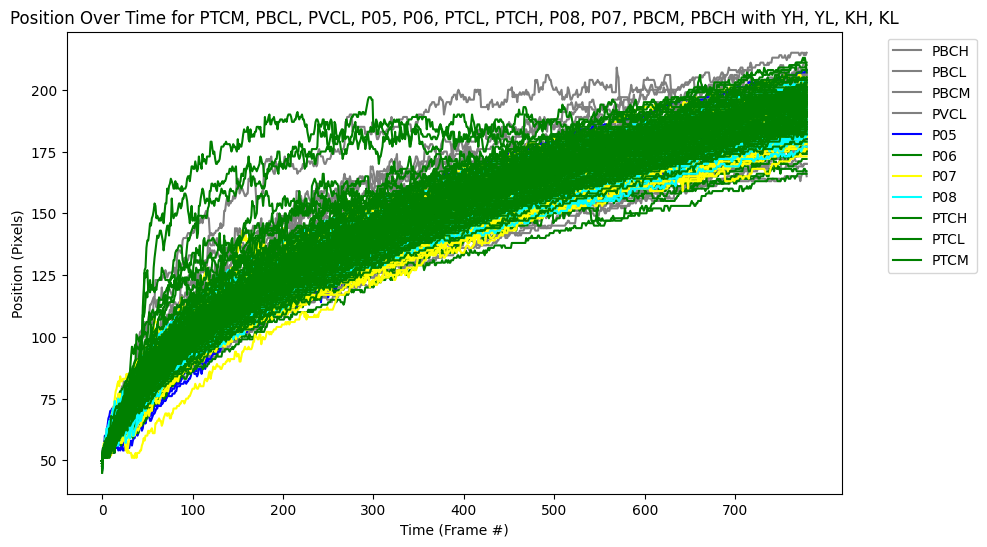

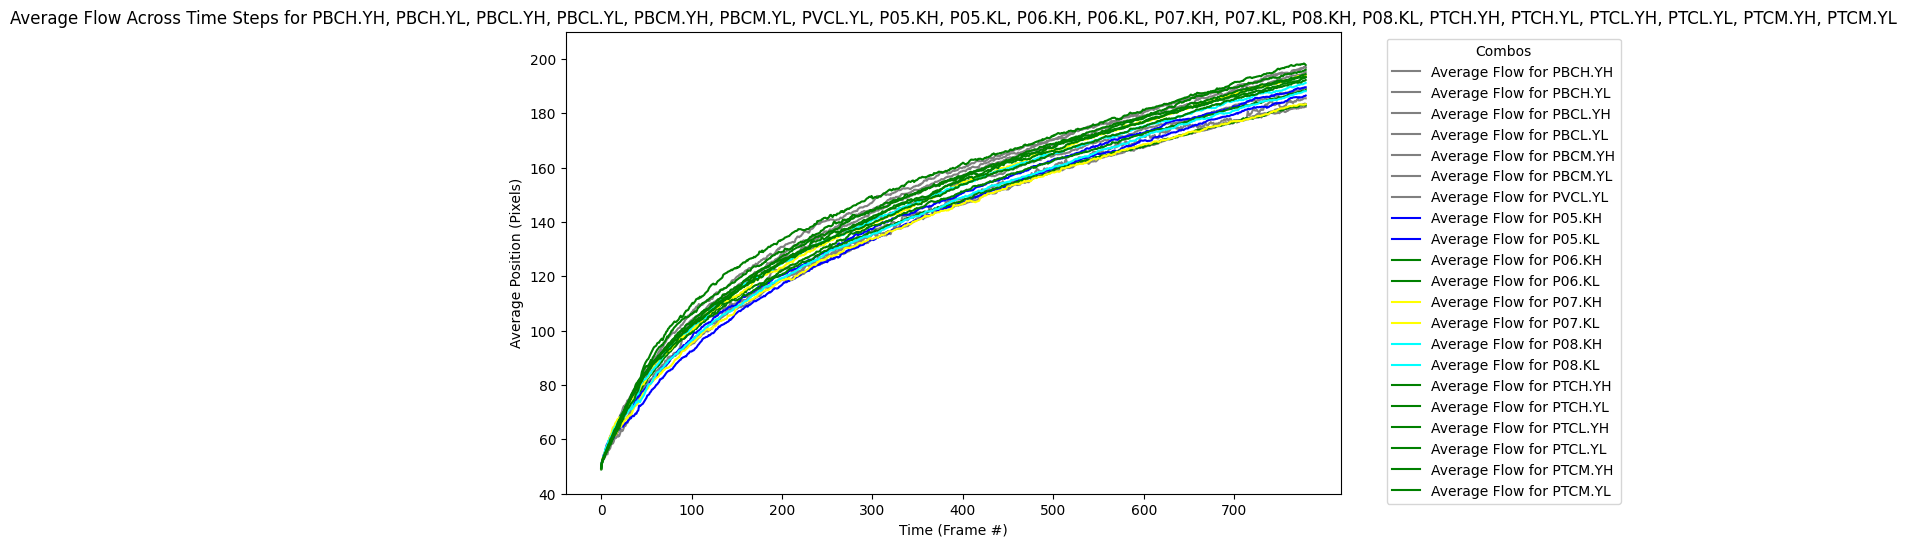

In [ ]:
""" Comparison Plots """
#need to make into a function
#inputs: names of files, plastics to include, reagents to include, channels to include, plot title, labeling column
#flag for if want average or raw

def PreClean(df_list, removeNullFlag=False):
  df_output = []
  for df in df_list:
    df.index.name = 'Index'
    df.rename(columns={
        'Channel.1': 'Channel'
    }, inplace=True)
    df[['Plastic', 'Reagent']] = df['Combo'].str.split('.', expand=True)
    df_output.append(df)
  df = pd.concat(df_output, ignore_index=True)
  if removeNullFlag:
    df = df[df['Reagent'].str[-1] != '0'] ##This check will remove all N0's as well!
  return df
#-------------------------------------------------------------------------------
def ComparisonPlot(df_all, plasticsIn=None, plasticsOut=None, reagentsIn=None, reagentsOut=None, channelsIn=None, channelsOut=None, printFlag=False, avgFlag=False, labelColumn='Plastic', plotTitle=None, comboList=None):
  if printFlag:
    display(df_all)
  filtered_df = df_all
  if plasticsIn is not None:
    filtered_df = filtered_df[filtered_df['Plastic'].isin(plasticsIn)]
  if plasticsOut is not None:
    filtered_df = filtered_df[~filtered_df['Plastic'].isin(plasticsOut)]
  if reagentsIn is not None:
    filtered_df = filtered_df[filtered_df['Reagent'].isin(reagentsIn)]
  if reagentsOut is not None:
    filtered_df = filtered_df[~filtered_df['Reagent'].isin(reagentsOut)]
  if channelsIn is not None:
    filtered_df = filtered_df[filtered_df['Channel'].isin(channelsIn)]
  if channelsOut is not None:
    filtered_df = filtered_df[~filtered_df['Channel'].isin(channelsOut)]
  time_columns = df.columns[3:-2]
  plt.figure(figsize=(10, 6))
  handles = []
  labels = []
  plastic_to_color = {
    'P04': 'magenta',
    'P03': 'red',
    'P02': 'orange',
    'P01': 'black',
    'P05': 'blue',
    'P06': 'green',
    'P07': 'yellow',
    'P08': 'cyan',
    'PMS': 'red',
    'PMC': 'lime',
    'PSS': 'blue',
    'PSC': 'cyan',
    'PTC': 'green'# You can add more plastic types here as needed
    # Add other plastic types and their corresponding colors
  }
  for _, row in filtered_df.iterrows():
    plastic_type = row['Plastic'][:3]
    color = plastic_to_color.get(plastic_type, 'gray')  # Default to 'gray' if not found
    label = row[labelColumn]
    line, = plt.plot(time_columns, row[3:-2], color=color, label=label)
    # Only add the first occurrence of a label to the legend
    if label not in labels:
        handles.append(line)
        labels.append(label)
  if plotTitle is not None:
    plt.title(plotTitle)
  else:
    plt.title(f'Position Over Time for {", ".join(set(labels))} with {", ".join(list(filtered_df["Reagent"].unique()))}')
  plt.xlabel('Time (Frame #)')
  plt.ylabel('Position (Pixels)')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', labels=labels, handles=handles)
  plt.xticks(ticks=range(0, len(time_columns), 100), labels=time_columns[::100])
  plt.show()

  if avgFlag:
    if comboList is None:
      combo_list = list(filtered_df['Combo'].unique())

    # Identify the flow columns (e.g., '0', '1', '2', '3', ... up to the last flow column)
    flow_columns = [str(i) for i in range(0, 780)]  # Adjust based on the actual range of columns

    # Create a plot
    plt.figure(figsize=(10, 6))

    # Loop over each Combo in the list
    for combo in combo_list:
        # Filter the rows for the current Combo
        group_df = df[df['Combo'] == combo]

        # Compute the average across time steps (columns) for all rows in the group
        average_flow_across_time = group_df[flow_columns].mean(axis=0)

        # Plot the average flow for the current Combo
        plastic_type = combo[:3]
        color = plastic_to_color.get(plastic_type, 'gray')
        line, = plt.plot(average_flow_across_time.index, average_flow_across_time.values, color=color, label=f'Average Flow for {combo}')
        #plt.plot(average_flow_across_time.index, average_flow_across_time.values, label=f'Average Flow for {combo}')

    # Adding titles and labels
    plt.title(f'Average Flow Across Time Steps for {", ".join(combo_list)}')
    plt.xlabel('Time (Frame #)')
    plt.ylabel('Average Position (Pixels)')
    plt.legend(title="Combos", bbox_to_anchor=(1.05, 1), loc='upper left')  # Adjust legend position
    plt.xticks(ticks=range(0, len(time_columns), 100), labels=time_columns[::100])
    plt.ylim(40, 210)
    plt.show()
#-------------------------------------------------------------------------------
exp1 = Path('/content/drive/MyDrive/Lexi/MNP/Round_2/2025.03.19.PBC400BW.2x3+1.Lysozyme.VS')
exp2 = Path('/content/drive/MyDrive/Lexi/MNP/Round_2/2025.03.18_2.BW.2x4+1.Lysine')
exp3 = Path('/content/drive/MyDrive/Lexi/MNP/Round_2/2025.03.18_1.PBC400BW.2x3+1.Lysine.VS')
exp4 = Path('/content/drive/MyDrive/Lexi/MNP/Round_2/2025.02.14.PTC400.2x3+1.Lysozyme.KH')
pos1 = pd.read_csv(exp1 / '2025.03.19.PBC400BW.2x3+1.Lysozyme.VS_Pos.csv', index_col=0)
pos2 = pd.read_csv(exp2 / '2025.03.18_2.BW.2x4+1.Lysine_Pos.csv', index_col=0)
pos3 = pd.read_csv(exp3 / '2025.03.18_1.PBC400BW.2x3+1.Lysine.VS_Pos.csv', index_col=0)
pos4 = pd.read_csv(exp4 / '2025.02.14.PTC400.2x3+1.Lysozyme.KH_Pos.csv', index_col=0)

df = PreClean([pos1, pos2, pos4], removeNullFlag=True)
#display(df)
ComparisonPlot(df, avgFlag=True)
#ComparisonPlot(df)







##Other

In [ ]:
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

def correlation_heatmap(data):
    num_features = data.shape[1]
    fig_size = 100  # or scale up more aggressively if needed

    _, ax = plt.subplots(figsize=(fig_size, fig_size))
    colormap = sns.diverging_palette(220, 10, as_cmap=True)

    sns.heatmap(
        data.corr(),
        cmap=colormap,
        square=True,
        cbar_kws={'shrink': .9},
        ax=ax,
        annot=False,
        linewidths=0.1,
        vmax=1.0,
        linecolor='white'
    )

    plt.title('Pearson Correlation of Features', y=1.05, size=15)
    plt.tight_layout()  # Helps prevent clipping
    plt.savefig('/content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data/20250304AIC_SIE_heatmapLR.png', dpi=72, bbox_inches='tight')  # High-res PNG
    plt.close()  # Closes the figure to free memory
    plt.show()

FitData = pd.read_csv('/content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data/20250304AIC_SIE.csv', index_col=0)
correlation_heatmap(FitData.iloc[:, 2:-1])

In [ ]:
from pickle import FALSE
""" To print out 2D grid of graphs for broad overview for data visualization"""


# Step 1: Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import files

##Think about adding standard deviation bars to graph (even tho they will be v large)




filename = '20250102AIC_combined.csv'
downloadFlag = False
combined_df = pd.read_csv('/content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data/' + filename)
output_file = '/content/drive/MyDrive/Lexi/MNP/Round_2/AIC_Data/' + filename[:-3] + 'png'


# Step 3: Ensure data has the correct column names
column_headers = ['Slope', 'WindowEdge', 'Combo', 'Plastic', 'Reagent', 'Channel', 'IC', 'Adjusted_Slope']
combined_df = combined_df[column_headers]

#Modify the 'Plastic' column entries that start with 'PC'
combined_df['Plastic'] = combined_df['Plastic'].apply(lambda x: 'SC' + x[1:] if x.startswith('C') else x)

# Step 4: Group the data by 'WindowEdge', 'Plastic', and 'Reagent', and calculate the average Adjusted_Slope
grouped_data = combined_df.groupby(['WindowEdge', 'Plastic', 'Reagent'])['Adjusted_Slope'].mean().reset_index()

# Step 5: Set up the plot styling
sns.set(style="whitegrid")

# Step 6: Get the unique values for 'WindowEdge' and 'Plastic'
window_edges = grouped_data['WindowEdge'].unique()
plastics = grouped_data['Plastic'].unique()

# Step 7: Calculate the number of subplots (grid size)
num_rows = len(window_edges)
num_cols = len(plastics)

# Step 8: Create a figure with subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 6, num_rows * 6))
fig.subplots_adjust(hspace=0.5, wspace=0.3)  # Adjust space between subplots

# Step 9: Flatten axes array for easy indexing
axes = axes.flatten()

# Step 10: Loop over each combination of 'WindowEdge' and 'Plastic' and create a bar plot for each
for i, (window_edge) in enumerate(window_edges):
    for j, (plastic) in enumerate(plastics):
        # Get the current subplot
        ax = axes[i * num_cols + j]

        # Filter the data for the current WindowEdge and Plastic
        subset = grouped_data[(grouped_data['WindowEdge'] == window_edge) & (grouped_data['Plastic'] == plastic)]

        # Create a bar plot
        #sns.barplot(x='Reagent', y='Adjusted_Slope', data=subset, palette='viridis', ax=ax)
        # Create a bar plot with standard deviation bars
        sns.barplot(x='Reagent', y='Adjusted_Slope', data=subset, palette='viridis', ax=ax, errorbar='sd', hue='Reagent', legend=False)



        # Set plot title and labels
        ax.set_title(f"WindowEdge = {window_edge}, Plastic = {plastic}")
        ax.set_xlabel('Reagent')
        ax.set_ylabel('Average Adjusted_Slope')
        ax.set_ylim(-5, 5)
        ax.tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# Step 11: Save the grid of plots as an image file
plt.savefig(output_file, bbox_inches='tight')  # Save the figure with tight layout
plt.close()  # Close the figure to avoid displaying it in Colab

if downloadFlag:
    files.download(output_file)
    print(f"Combined plot downloaded")
else:
    print(f"Combined plot saved to: {output_file}")


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x782515326b00> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7825153257e0> (for post_execute):


KeyboardInterrupt: 

In [ ]:


#### Deorpricated!!!! (backup) ####



longFlag = True #if want to generate AIC25s files, which are AIC files with more time steps
kFlag_raw = True #if want to generate k values, where L = ksqrt(t) for the curves, no ic consideration
kFlag_diff = True #k value difference between cha and ic

directory_path = Path('/content/drive/MyDrive/Lexi/MNP/Round_2')
directory_files = directory_path.iterdir()
folders_to_process_aic = []
folders_complete_aic = []
folders_to_process_pos = []
folders_complete_pos = []
folders_complete_plot = []
folders_to_process_plot = []
folders_complete_aic25s = []
folders_to_process_aic25s = []
folders_to_process_k = []
folders_complete_k = []
folders_to_process_k_diff = []
folders_complete_k_diff = []

for folder in directory_files:
    if folder.is_dir() and (folder.name.startswith("2024") or folder.name.startswith("2025")):
        experiment_files = list(folder.iterdir())
        aic_files = [file for file in experiment_files if file.name.endswith('_aic.csv')]
        if aic_files:
            folders_complete_aic.append(folder)
        else:
            folders_to_process_aic.append(folder)
        pos_files = [file for file in experiment_files if file.name.endswith('_Pos.csv')]
        if pos_files:
            folders_complete_pos.append(folder)
        else:
            folders_to_process_pos.append(folder)
        plot_files = [file for file in experiment_files if file.name.endswith('_Plots.pdf')]
        if plot_files:
            folders_complete_plot.append(folder)
        else:
            folders_to_process_plot.append(folder)
        aic25s_files = [file for file in experiment_files if file.name.endswith('_aic25s.csv')]
        if aic25s_files:
            folders_complete_aic25s.append(folder)
        else:
            folders_to_process_aic25s.append(folder)
        k_raw_files = [file for file in experiment_files if file.name.endswith('_k.csv')]
        if k_raw_files:
            folders_complete_k.append(folder)
        else:
            folders_to_process_k.append(folder)
        k_diff_files = [file for file in experiment_files if file.name.endswith('_kdiff.csv')]
        if k_diff_files:
            folders_complete_k_diff.append(folder)
        else:
            folders_to_process_k_diff.append(folder)
folders_to_process_aic = sorted(folders_to_process_aic)
folders_to_process_pos = sorted(folders_to_process_pos)
folders_to_process_plot = sorted(folders_to_process_plot)
folders_to_process_aic25s = sorted(folders_to_process_aic25s)
folders_to_process_k = sorted(folders_to_process_k)
folders_to_process_k_diff = sorted(folders_to_process_k_diff)
folders_complete_aic = sorted(folders_complete_aic)
folders_complete_pos = sorted(folders_complete_pos)
folders_complete_plot = sorted(folders_complete_plot)
folders_complete_aic25s = sorted(folders_complete_aic25s)
folders_complete_k = sorted(folders_complete_k)
folders_complete_k_diff = sorted(folders_complete_k_diff)

print(f"AIC: There are {len(folders_to_process_aic)} to process and {len(folders_complete_aic)} complete")
print(f"POS: There are {len(folders_to_process_pos)} to process and {len(folders_complete_pos)} complete")
print(f"PLOT: There are {len(folders_to_process_plot)} to process and {len(folders_complete_plot)} complete")
print(f"AIC25s: There are {len(folders_to_process_aic25s)} to process and {len(folders_complete_aic25s)} complete; flag is {longFlag}")
print(f"k: There are {len(folders_to_process_k)} to process and {len(folders_complete_k)} complete; flag is {kFlag_raw}")
print(f"k_diff: There are {len(folders_to_process_k_diff)} to process and {len(folders_complete_k_diff)} complete; flag is {kFlag_diff}")

if longFlag:
  folders_to_process = list(set(folders_to_process_aic + folders_to_process_aic25s + folders_to_process_pos + folders_to_process_plot))
else:
  folders_to_process = list(set(folders_to_process_aic + folders_to_process_pos + folders_to_process_plot))

if kFlag_raw:
  folders_to_process = list(set(folders_to_process + folders_to_process_k))
if kFlag_diff:
  folders_to_process = list(set(folders_to_process + folders_to_process_k_diff))

for i, folder in enumerate(folders_to_process, 1):
    easyName = folder.name
    print(f"\nProcessing folder {i} of {len(folders_to_process)}: \033[1m{easyName}\033[0m")
    data_folder_path = folder / 'Data'
    data_files = list(data_folder_path.iterdir())
    gsheet_files = [file for file in data_files if file.name.endswith('.gsheet')]
    xlsx_files = [file for file in data_files if file.name.endswith('.xlsx')]
    if len(xlsx_files) > 0:
        gsheet_files.extend(xlsx_files)
    mp4_files = [file for file in data_files if file.name.endswith('.mp4')]
    gsheet_count = len(gsheet_files)
    mp4_count = len(mp4_files)
    print(f'gsheets: {gsheet_count}    mp4s: {mp4_count}')
    aicFlag = False
    posFlag = False
    plotpdfFlag = False
    aic25sFlag = False
    k_calc_flag = False
    k_diff_calc_flag = False
    if gsheet_count < mp4_count and mp4_count > 0:
        print(f'Fewer gsheets than mp4s found for {easyName}')
        print(f'Processing videos for {easyName}')
        BatchProcessVideos(data_folder_path, mp4_files, folder)
    if (gsheet_count > 0 and mp4_count > 0 and gsheet_count == mp4_count) or (gsheet_count > 0 and mp4_count == 0):
        folderID = str(get_id(data_folder_path))
        # Updated query to include both Google Sheets and .xlsx files
        q = f"'{folderID}' in parents and (mimeType = 'application/vnd.google-apps.spreadsheet' or mimeType = 'application/vnd.openxmlformats-officedocument.spreadsheetml.sheet')"
        FlowDataList = drive.ListFile({'q': q}).GetList()
        if folder in folders_to_process_aic:
            aicFlag = True
        if folder in folders_to_process_pos:
            posFlag = True
        if folder in folders_to_process_plot:
            plotpdfFlag = True
        if folder in folders_to_process_aic25s:
          aic25sFlag = True
        if folder in folders_to_process_k:
          k_calc_flag = True
        if folder in folders_to_process_k_diff:
          k_diff_calc_flag = True
        if aicFlag | posFlag | plotpdfFlag | aic25sFlag | k_calc_flag | k_diff_calc_flag:
            GenerateAICPOSPLOTS(FlowDataList, easyName, data_folder_path.parent, aicFlag=aicFlag, posFlag=posFlag, plotpdfFlag=plotpdfFlag, aic25sFlag=aic25sFlag, k_calc_flag=k_calc_flag, k_diff_calc_flag=k_diff_calc_flag)

AIC: There are 0 to process and 110 complete
POS: There are 0 to process and 110 complete
PLOT: There are 0 to process and 110 complete
AIC25s: There are 0 to process and 110 complete; flag is True
k: There are 0 to process and 110 complete; flag is True
k_diff: There are 0 to process and 110 complete; flag is True
